# Programming in Python II - Final Coding Project

Author: Ebenezer Ikechukwu Ozumah

Student ID: 12455349

Save this file under a file name in the format k+matriculation_number.ipynb, e.g. *k1234567.ipynb*. Remember that for final submission all code cells must run without errors and all cells have to be evaluated.

The code cells are a basic scaffold - you can of course add new code cells if necessary. However, stick to the overall structure of the template to facilitate grading. Ensure to comment your code and structure it reasonably.

In [63]:
# This is just a minimum setup for reproducibility. Add more libraries as required.

import numpy as np
import torch
import matplotlib.pyplot as plt
import os
from tqdm import tqdm
import zipfile
from pathlib import Path

RANDOM_SEED = 42
IN_COLAB = False
FINAL_PROJECT_SATELLITE_IMAGE_CLASSIFICATION_DIR = "."
BATCH_SIZE = 64


# Setting device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if torch.backends.mps.is_available():
    device = torch.device("mps")

# Set random seeds for reproducibility
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

In [64]:
# checking successful setup
print(f"Using device: {device}")

Using device: mps


## Colab config for data access from google derive and GPU usage

In [65]:
try:
    from google.colab import drive
    IN_COLAB = True
    FINAL_PROJECT_SATELLITE_IMAGE_CLASSIFICATION_DIR = "/content/drive/MyDrive/final_project_satellite_Image_classification"
except ModuleNotFoundError:
    IN_COLAB = False
    FINAL_PROJECT_SATELLITE_IMAGE_CLASSIFICATION_DIR = "."
    drive = None

if IN_COLAB:
    drive.mount('/content/drive', force_remount=True)
else:
    print("Running on a local kernel; skipping Google Drive mount.")

Running on a local kernel; skipping Google Drive mount.


### Extract data to google drive (Because Google colab uses Virtual machine and its root directory is cloud)

In [66]:
def set_up_data(in_colab: bool, dir, zip, folder):
    if in_colab and zip.exists() and not folder.exists():
        print("Dataset ZIP found and extracted folder is missing. Unzipping...")

        with zipfile.ZipFile(zip, "r") as zf:
            zf.extractall(dir)

        print("Dataset extracted to:", dir)
    
    elif folder.exists():
        print("Dataset folder already exists; skipping unzip.")
    else:
        print("No dataset ZIP found to extract in this environment.")


project_dir = Path(FINAL_PROJECT_SATELLITE_IMAGE_CLASSIFICATION_DIR).expanduser()
data_zip = project_dir / "data.zip"
data_folder = project_dir / "data"

public_test_data_zip = project_dir / "public_test_data.zip"
public_test_data_folder = project_dir / "public_test_data"

set_up_data(IN_COLAB, project_dir, data_zip, data_folder)
set_up_data(IN_COLAB, project_dir, public_test_data_zip, public_test_data_folder)


Dataset folder already exists; skipping unzip.
Dataset folder already exists; skipping unzip.


In [67]:
# For visualization in Jupyter notebooks
%matplotlib inline

In [68]:
# Set working directory to the project folder
os.chdir(FINAL_PROJECT_SATELLITE_IMAGE_CLASSIFICATION_DIR)  # Change this to your project folder path
print(f"Current working directory: {os.getcwd()}")

Current working directory: /Users/mac/Documents/JKU_COURSE/cod3s/programming_in_python_II/final_project_satellite_Image_classification


In [69]:
# creating folder 'assets' if necessary
os.makedirs("assets", exist_ok=True)

## Data Handling and Pre-Processing

In [70]:
# ------- PREPROCESS DATA -----
import pandas as pd

def preprocess(data_folder: str) -> tuple[pd.DataFrame, dict]:
    
    """Processed the data from the data folder path provided,

    Args:
        data_folder (str): The path of the folder containing the data files ( - images in its class type folder)

    Returns:
        tuple[
            pd.Dataframe: A dataframe containing the processed data (index, folder(str), file_name(str), label (int)).
            dict: A dictionary containing the class labels and their corresponding indices.
        ]
    """
    class_labels_list = sorted(os.listdir(data_folder))
    class_labels_dict = {label: idx for idx, label in enumerate(class_labels_list)}

    # print(f"Class Labels Dict: {class_labels_dict}")
    # print(f"Class Labels List: {class_labels_list}")

    satellite_data = []

    for class_name in tqdm(class_labels_list):
        folder = os.path.join(data_folder, class_name)

        file_names = os.listdir(folder) # lists all the files in a class folder

        for file_name in file_names:
            satellite_data.append({
                "folder": folder,
                "file_name": file_name,
                "label": class_labels_dict[class_name]
            })
    df_satellite_data = pd.DataFrame(satellite_data)
    return df_satellite_data, class_labels_dict
    ...


In [71]:
# checking successful dataframe loading

df_satellite_data, labels = preprocess("data")
class_labels = [label_name for label_name, label in labels.items()]

print(f"Length of dataset: {len(df_satellite_data)}")
df_satellite_data

100%|██████████| 10/10 [00:00<00:00, 171.66it/s]

Length of dataset: 10000


,folder,file_name,label
0,data/AnnualCrop,AnnualCrop_1372.jpg,0
1,data/AnnualCrop,AnnualCrop_1366.jpg,0
2,data/AnnualCrop,AnnualCrop_2109.jpg,0
3,data/AnnualCrop,AnnualCrop_1428.jpg,0
4,data/AnnualCrop,AnnualCrop_2874.jpg,0
...,...,...,...
9995,data/SeaLake,SeaLake_2888.jpg,9
9996,data/SeaLake,SeaLake_1359.jpg,9
9997,data/SeaLake,SeaLake_809.jpg,9
9998,data/SeaLake,SeaLake_612.jpg,9


In [72]:
# (splitting train/validation datasets)
from sklearn.model_selection import train_test_split

df_training_data, df_validation_data = train_test_split(
    df_satellite_data,
    test_size=0.2,
    random_state=RANDOM_SEED
)

print(f"Training Dataset Length: {len(df_training_data)}")
print(f"Validation Dataset Length: {len(df_validation_data)}")

Training Dataset Length: 8000
Validation Dataset Length: 2000


## Exploratory Data Analysis (EDA)

5 Random Samples


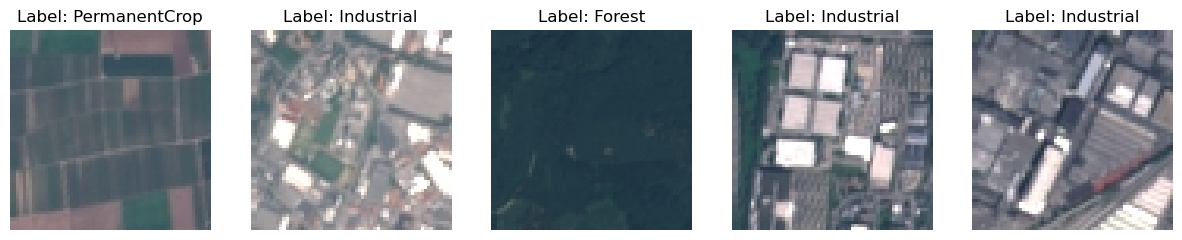

In [ ]:
%matplotlib inline
# SHOW SAMPLES
from PIL import Image

def show_samples(df: pd.DataFrame, num_samples: int = 5) -> None:
    """Selects random num_samples images from the dataframe provided and displays them in grid (1 * 5), 
        Saves the plot in the directory assets/plot with the name random_samples.png
    
    Args:
        df (pd.DataFrame): dataframe of the data to select random sample from.
        num_samples (int): Number of samples to select.
    
    Returns:
        None
    """
    print(f"{num_samples} Random Samples")

    # random_samples = df.sample(n=num_samples) # Without random
    random_samples = df.sample(n=num_samples, random_state=RANDOM_SEED)

    plt.figure(figsize=(15, 3))

    for i, (idx, sample) in enumerate(random_samples.iterrows()):
        # print(f"idx: {idx} | folder: {sample["folder"]} | file_name: {sample["file_name"]} | label: {sample["label"]}")

        folder = sample["folder"]
        file_name = sample["file_name"]
        label = sample["label"]

        image_full_path = os.path.join(folder, file_name)
        image = Image.open(image_full_path)

        # TODO: Implement Multiple rows and columns to enable display of more than 5 samples

        plt.subplot(1, num_samples, i + 1)
        plt.imshow(image)
        plt.title(f"Label: {class_labels[label]}")
        plt.axis("off")
        os.makedirs("assets/plots", exist_ok=True)
        plt.savefig("assets/plots/random_samples.png")


show_samples(df_satellite_data, num_samples=5)

Calculating Average Pixel Values:  10%|▉         | 782/8000 [00:00<00:01, 3972.31it/s]

Image shape: [[25 25 24 ... 25 24 25]
 [25 24 24 ... 26 25 25]
 [25 25 25 ... 25 25 25]
 ...
 [24 24 24 ... 25 23 25]
 [25 25 25 ... 25 25 26]
 [26 26 25 ... 25 25 25]]


Calculating Average Pixel Values: 100%|██████████| 8000/8000 [00:01<00:00, 4038.11it/s]


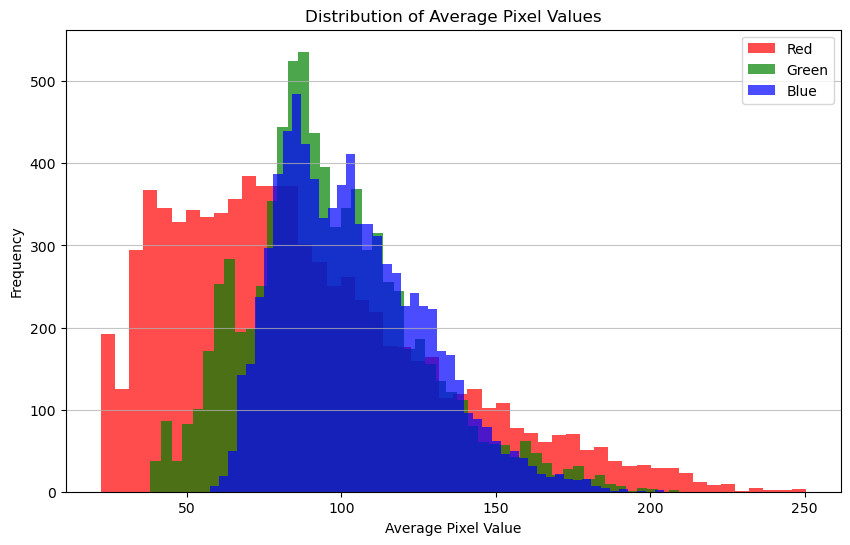

In [74]:
%matplotlib inline
# Average pixel plot
def average_pixel_plot(df: pd.DataFrame) -> None:
    """Plots the distribution of the average pixel values in the three color channels in the training set,
        Saves the plot in the directory `assets/plots` with the filename `average_pixel_distribution.png`
    
    Args:
        df (pd.DataFrame): dataframe for the training dataset
    
    Returns:
        None
    """
    average_red, average_green, average_blue = [], [], []

    for i, (idx, sample) in tqdm(enumerate(df.iterrows()), total=len(df), desc="Calculating Average Pixel Values"):
        folder = sample["folder"]
        file_name = sample["file_name"]

        image_full_path = os.path.join(folder, file_name)
        image = Image.open(image_full_path)

        # Convert the image to RGB if it's not already in that mode
        if image.mode != "RGB":
            image = image.convert("RGB")

        # Convert the image to a numpy array
        image_array = np.array(image)
        if i == 0:
            # print(f"Image shape: {image_array}")
            print(f"Image shape: {image_array[:, :, 0]}")

        red_mean = np.mean(image_array[:, :, 0])
        green_mean = np.mean(image_array[:, :, 1])
        blue_mean = np.mean(image_array[:, :, 2])

        # Calculate the average pixel values for each color channel
        average_red.append(red_mean)
        average_green.append(green_mean)
        average_blue.append(blue_mean)
    
    # Plotting distribution for all(RGB) color channels
    plt.figure(figsize=(10, 6))
    plt.hist(average_red, bins=50, alpha=0.7, label="Red", color="red")
    plt.hist(average_green, bins=50, alpha=0.7, label="Green", color="green")
    plt.hist(average_blue, bins=50, alpha=0.7, label="Blue", color="blue")
    plt.title("Distribution of Average Pixel Values")
    plt.xlabel("Average Pixel Value")
    plt.ylabel("Frequency")
    plt.legend()
    plt.grid(axis="y", alpha=0.75)
    os.makedirs("assets/plots", exist_ok=True)
    plt.savefig("assets/plots/average_pixel_distribution.png")
    plt.show()

average_pixel_plot(df=df_training_data)

Calculating Average Brightness Per Class: 100%|██████████| 8000/8000 [00:01<00:00, 6253.55it/s]


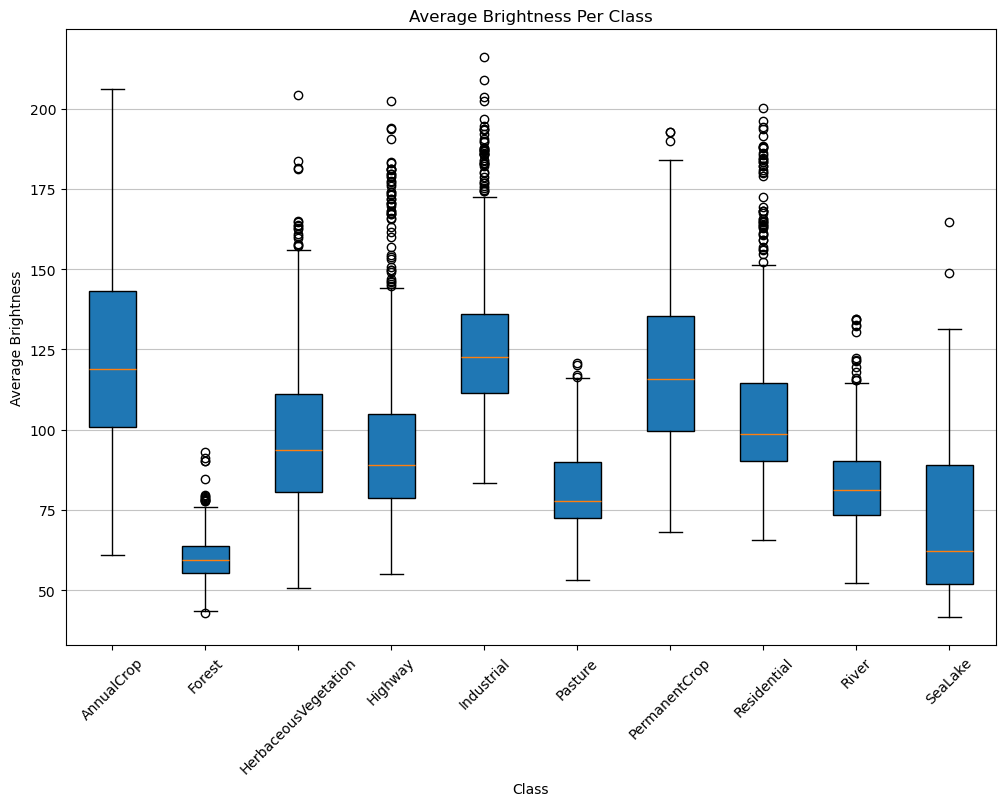

In [75]:
%matplotlib inline
# Average brightness per class
def average_brightness_per_class(df: pd.DataFrame) -> None:
    """Calculates and plots the average brightness of the images per class in the training set,
        Saves the plot in the directory `assets/plots` with the filename `average_brightness_per_class.png`
    
    Args:
        df (pd.DataFrame): dataframe for the training dataset
    
    Returns:
        None
    """
    class_brightness = {label: [] for label in class_labels}

    for i, (idx, sample) in tqdm(enumerate(df.iterrows()), total=len(df), desc="Calculating Average Brightness Per Class"):
        folder = sample["folder"]
        file_name = sample["file_name"]
        label = sample["label"]

        image_full_path = os.path.join(folder, file_name)
        image = Image.open(image_full_path)

        # Convert the image to RGB if it's not already in that mode
        if image.mode != "RGB":
            image = image.convert("RGB")

        # Convert the image to a numpy array
        image_array = np.array(image)

        # Calculate the average brightness as the mean of the average pixel values across all color channels
        brightness = np.mean(image_array)

        class_brightness[class_labels[label]].append(brightness)
    
    # print(class_brightness)
    
    # Plotting the average brightness per class
    plt.figure(figsize=(12, 8))
    plt.boxplot(class_brightness.values(), tick_labels=class_brightness.keys(), patch_artist=True)
    plt.title("Average Brightness Per Class")
    plt.xlabel("Class")
    plt.ylabel("Average Brightness")
    plt.xticks(rotation=45)
    plt.grid(axis="y", alpha=0.75)
    os.makedirs("assets/plots", exist_ok=True)
    plt.savefig("assets/plots/average_brightness_per_class.png")
    plt.show()

average_brightness_per_class(df=df_training_data)

## CNN Implementation and Training

### Dataset class

In [76]:
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

# Training transformer
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(size=128, scale=(0.8, 1.0), ratio=(0.9, 1.1)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Validation transformer
validation_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])


class SatelliteDataset(Dataset):
    """Custom Satellite dataset"""
    def __init__(self, df: pd.DataFrame, transform=None):
        """
        Args:
            df (pd.DataFrame): The DataFrame containing the image paths and labels.
            transform (transforms.Compose, optional): The transformations to apply to the images.
        """
        self.df = df.reset_index(drop=True)
        self.transform = transform
        self.targets = self.df["label"].tolist()

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        folder = row["folder"]
        file_name = row["file_name"]
        label = row["label"]

        img_full_path = os.path.join(folder, file_name)

        img = Image.open(img_full_path).convert("RGB")

        if self.transform:
            img = self.transform(img)

        return img, label


### Data Loaders

In [77]:
# Initializing datasets
training_dataset = SatelliteDataset(df_training_data, transform=train_transform)
validation_dataset = SatelliteDataset(df_validation_data, transform=validation_transform)

# DataLoaders for training and validation datasets
training_dataloader = DataLoader(training_dataset, batch_size=BATCH_SIZE, shuffle=True)
validation_dataloader = DataLoader(validation_dataset, batch_size=BATCH_SIZE, shuffle=False)

training_dataloader, validation_dataloader

(<torch.utils.data.dataloader.DataLoader at 0x306da8770>,
 <torch.utils.data.dataloader.DataLoader at 0x1082617f0>)

### Model Architecture

In [78]:
# Implementation of SatelliteModel
from torch import nn
import torch.nn.functional as F

class SatelliteModel(nn.Module):
    def __init__(self, input_shape, output_shape, hidden_units=128):
        """Initializes the Satellite multi-class classification model

        Args:
            input_shape (tuple): The shape of the input images (C, H, W).
            output_shape (int): The number of output classes.
            hidden_units (int, optional): The number of hidden units in the fully connected layer.-- defaults: 128.
        """
        super().__init__()
        self.convolutional_block_1 = nn.Sequential(
            nn.Conv2d(input_shape, hidden_units, 3, padding=1),
            nn.BatchNorm2d(hidden_units),
            nn.ReLU(),
            nn.Conv2d(hidden_units, hidden_units, 3, padding=1),
            nn.BatchNorm2d(hidden_units),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        
        self.convolutional_block_2 = nn.Sequential(
            nn.Conv2d(hidden_units, hidden_units, 3, padding=1),
            nn.BatchNorm2d(hidden_units),
            nn.ReLU(),
            nn.Conv2d(hidden_units, hidden_units, 3, padding=1),
            nn.BatchNorm2d(hidden_units),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        
        self.convolutional_block_3 = nn.Sequential(
            nn.Conv2d(hidden_units, hidden_units, 3, padding=1),
            nn.BatchNorm2d(hidden_units),
            nn.ReLU(),
            nn.Conv2d(hidden_units, hidden_units, 3, padding=1),
            nn.BatchNorm2d(hidden_units),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        
        self.convolutional_block_4 = nn.Sequential(
            nn.Conv2d(hidden_units, hidden_units, 3, padding=1),
            nn.BatchNorm2d(hidden_units),
            nn.ReLU(),
            nn.Conv2d(hidden_units, hidden_units, 3, padding=1),
            nn.BatchNorm2d(hidden_units),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((4, 4)),
            nn.Flatten(),
            nn.Dropout(p=0.4),
            nn.Linear(in_features=hidden_units * 4 * 4, out_features=256),
            nn.ReLU(),
            nn.Dropout(p=0.4),
            nn.Linear(in_features=256, out_features=output_shape)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Performs a forward pass through the model

        Args:
            x (torch.Tensor): The input tensor of shape (B, C, H, W)

        Returns:
            torch.Tensor: The output tensor of shape (B, output_shape)
        """
        x = self.convolutional_block_1(x)
        # print(f"Shape after convolutional_block_1: {x.shape}")

        x = self.convolutional_block_2(x)
        # print(f"Shape after convolutional_block_2: {x.shape}")

        x = self.convolutional_block_3(x)
        # print(f"Shape after convolutional_block_3: {x.shape}")

        x = self.convolutional_block_4(x)
        # print(f"Shape after convolutional_block_4: {x.shape}")

        x = self.classifier(x)
        return x

In [79]:
# Initialize model
torch.manual_seed(RANDOM_SEED)
torch.cuda.manual_seed(RANDOM_SEED)

satellite_model = SatelliteModel(input_shape=3, output_shape=len(class_labels), hidden_units=128).to(device)
total_params = sum(p.numel() for p in satellite_model.parameters())

print(f"{satellite_model} \n \n Model Device: {next(satellite_model.parameters()).device}")
print(f"Total Number of Model Parameters: {total_params}")

SatelliteModel(
  (convolutional_block_1): Sequential(
    (0): Conv2d(3, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (convolutional_block_2): Sequential(
    (0): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, 

#### Loss function, optimizer and accuracy function

In [80]:
!pip install torchmetrics

In [81]:
# Implementation of loss function, optimizer, accuracy function
from torchmetrics import Accuracy

loss_fn = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(params=satellite_model.parameters(), lr=1e-3)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer=optimizer,
    mode="min",
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    # verbose=True
)


#### Evaluating the shape of the input image to understand the shape to passes through the model

In [82]:
# Evaluating the shape of the input image(with a single input image from the train dataset)

single_image, single_label = training_dataset[0]
print(f"Single Image Shape -- Before unsqueeze: {single_image.shape} | After unsqueeze: {single_image.unsqueeze(dim=0).shape}")  # Adding a dimension for the single image tensor (A dimension of 1 as this is a single image))

untrained_output = satellite_model(single_image.unsqueeze(dim=0).to(device))
untrained_output

Single Image Shape -- Before unsqueeze: torch.Size([3, 128, 128]) | After unsqueeze: torch.Size([1, 3, 128, 128])


tensor([[-0.3480, -0.3507, -0.1476,  0.0759,  0.2165,  0.0907, -0.3259, -0.4976,
          0.0005, -0.0718]], device='mps:0', grad_fn=<LinearBackward0>)

### Helper functions

In [83]:
def calculate_and_print_train_time(start_time: float, end_time: float) -> float:
    total_time = end_time - start_time
    print(f"Total time: {total_time}")
    return total_time

#### Evaluating Untrained Model

In [84]:
from tqdm import tqdm

satellite_model.eval()

loss = 0
acc = 0
satellite_model.eval()
with torch.inference_mode():
    for (X, y) in tqdm(validation_dataloader):
        # Move data and labels to device
        X, y = X.to(device), y.to(device)

        # Forward pass
        untrained_y_logits = satellite_model(X)
        untrained_y_pred = torch.softmax(untrained_y_logits, dim=1).argmax(dim=1)

        # Calculate the loss and accuracy
        loss += loss_fn(untrained_y_logits, y)
        acc +=  (untrained_y_pred == y).float().mean().item()

    # Calculate the average loss and accuracy
    loss /= len(validation_dataloader)
    acc /= len(validation_dataloader)

print(r"-------------------------------------------|")
print(f"Result for Evaluation of untrained model")
print(f"Loss: {loss:.5f} | Accuracy: {acc:.2f}")
print(r"-------------------------------------------|")

100%|██████████| 32/32 [00:12<00:00,  2.59it/s]

-------------------------------------------|
Result for Evaluation of untrained model
Loss: 2.30456 | Accuracy: 0.09
-------------------------------------------|


### Training Loop

In [ ]:
# Training and validation loop of the model
from timeit import default_timer as timer
from tqdm.auto import tqdm

torch.manual_seed(RANDOM_SEED)
torch.cuda.manual_seed(RANDOM_SEED)

start_training_time = timer()

epochs = 50

early_stop_patience = 10
best_val_loss = float("inf")
patience_counter = 0

train_losses, val_losses = [], []
train_accs, val_accs = [], []

for epoch in tqdm(range(epochs)):
    print("==============================================|")
    print(f"Epoch: {epoch}")

    # ----- TRAINING -----
    train_loss = 0
    train_acc = 0

    # Set model to training mode
    satellite_model.train()

    for batch, (X_train, y_train) in enumerate(training_dataloader):
        # Send X_train and y_train to device
        X_train, y_train = X_train.to(device), y_train.to(device)

        # Forward pass training data
        y_pred_logits = satellite_model(X_train)
        y_pred_labels = y_pred_logits.argmax(dim=1)

        # Calculate the loss and accuracy
        loss = loss_fn(y_pred_logits, y_train)
        #? acc = accuracy_fn(y_pred_labels.cpu(), y_train.cpu())
        acc = (y_pred_labels == y_train).float().mean()

        if batch % 50 == 0:
            print(f"Seen {(batch + 1) * len(X_train)} of {len(training_dataloader.dataset)}")

        # Calculate the total loss (add batch loss to total loss)
        train_loss += loss.item()
        train_acc += acc.item()

        # Optimizer zero grad
        optimizer.zero_grad()

        # Back propagation
        loss.backward()

        # Gradient descent
        optimizer.step()
    
    # Calculate the average loss and accuracy per epoch per epoch 
    train_loss /= len(training_dataloader)
    train_acc /= len(training_dataloader)

    train_losses.append(train_loss)
    train_accs.append(train_acc)


    # ----- VALIDATION -----
    val_loss = 0
    val_acc = 0

    satellite_model.eval()
    with torch.inference_mode():
        for (X_val, y_val) in validation_dataloader:
            # Send X_val and y_val to device
            X_val, y_val = X_val.to(device), y_val.to(device)

            # Forward pass
            val_y_pred_logits = satellite_model(X_val)
            val_y_pred_labels = val_y_pred_logits.argmax(dim=1)

            # Calculate the val loss and accuracy
            val_loss += loss_fn(val_y_pred_logits, y_val).item()
            val_acc += (val_y_pred_labels == y_val).float().mean().item()
        
        # Calculate the val loss and val accuracy average per batch
        val_loss /= len(validation_dataloader)
        val_acc /= len(validation_dataloader)

        val_losses.append(val_loss)
        val_accs.append(val_acc)

        scheduler.step(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            os.makedirs("assets/weights", exist_ok=True)
            torch.save(satellite_model.state_dict(), "assets/weights/best_model.pt")
        else:
            patience_counter += 1
            if patience_counter >= early_stop_patience:
                print("Early stopping triggered!")
                break
    
    # Print what is happening -- Average loss and accuracy per `batch`
    print("-----------------------------------------------|")
    print(f"Train Loss: {train_loss:.5f} | Train Accuracy: {train_acc:.2f}")
    print(f"Val Loss:  {val_loss:.5f} | Val Accuracy:  {val_acc:.2f}")
    print(f"==============================================|\n")


end_training_time = timer()
total_satellite_train_and_val_time = calculate_and_print_train_time(start_time=start_training_time, end_time=end_training_time)

  0%|          | 0/50 [00:00<?, ?it/s]

==============================================|
Epoch: 0
Seen 64 of 8000
Seen 3264 of 8000
Seen 6464 of 8000
-----------------------------------------------|
Train Loss: 1.55663 | Train Accuracy: 0.42
Val Loss:  1.21499 | Val Accuracy:  0.53
==============================================|

==============================================|
Epoch: 1
Seen 64 of 8000
Seen 3264 of 8000
Seen 6464 of 8000


## Model Evaluation

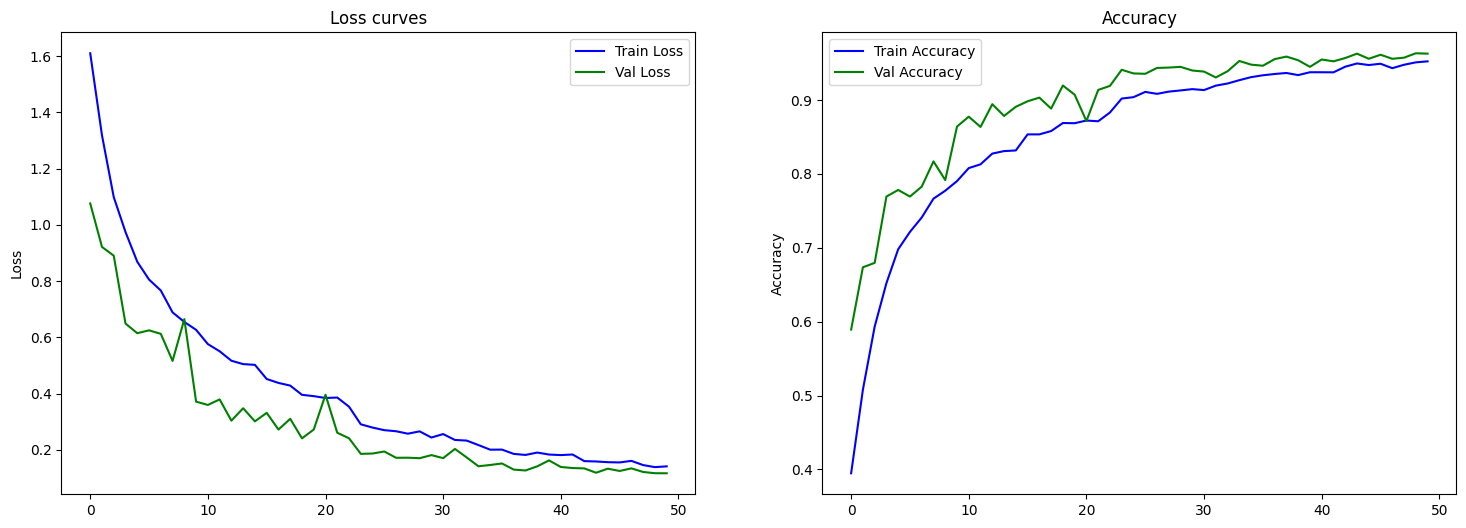

In [ ]:
%matplotlib inline
### ------ TRAINING CURVES -------

def plot_training_curves(train_losses, train_accs, val_losses, val_accs):
    plt.figure(figsize=(18, 6))

    # Plot for losses
    plt.subplot(1, 2, 1)
    plt.plot(train_losses, c="b", label="Train Loss")
    plt.plot(val_losses, c="g", label="Val Loss")
    plt.ylabel("Loss")
    plt.title("Loss curves")
    plt.legend()
    
    # Plot for Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(train_accs, c="b", label="Train Accuracy")
    plt.plot(val_accs, c="g", label="Val Accuracy")
    plt.ylabel("Accuracy")
    plt.title("Accuracy")
    plt.legend()

    os.makedirs("assets/plots", exist_ok=True)
    plt.savefig("assets/plots/training_curves.png")
    plt.show()


plot_training_curves(train_losses, train_accs, val_losses, val_accs)


  0%|          | 0/63 [00:00<?, ?it/s]

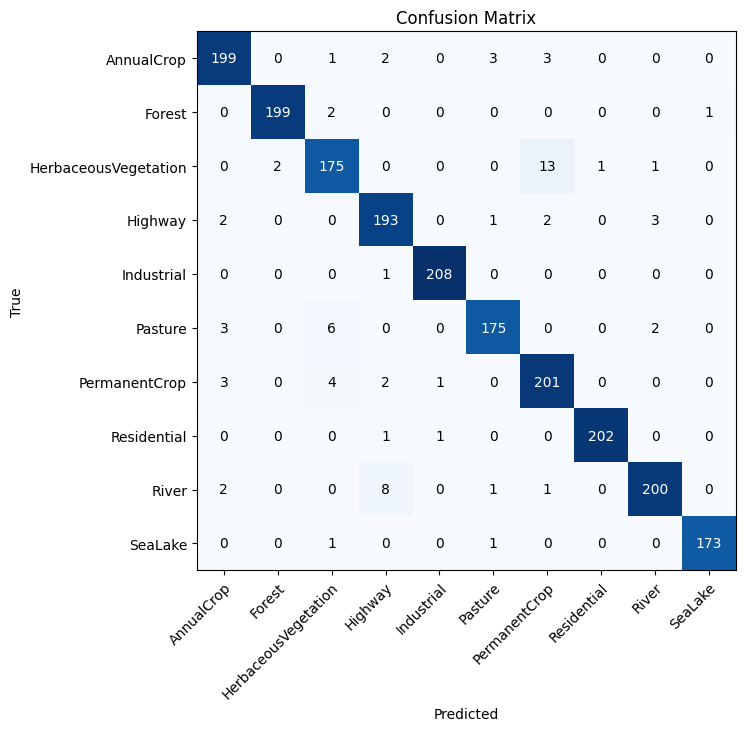

In [ ]:
%matplotlib inline
### ------ CONFUSION MATRIX ---------

# Import tqdm.auto
from tqdm.auto import tqdm 
from torchmetrics import ConfusionMatrix
from mlxtend.plotting import plot_confusion_matrix

def plot_confusion_matrix_fn(model: nn.Module, data_loader: torch.utils.data.DataLoader):

    y_preds = []
    y_trues = []

    model.eval()
    with torch.inference_mode():
        for (X, y) in tqdm(data_loader):
            # Move data and labels to device
            X, y = X.to(device), y.to(device)

            # Forward pass
            y_logits = model(X)
            y_pred = torch.softmax(y_logits, dim=1).argmax(dim=1)
            y_preds.append(y_pred.cpu())
            y_trues.append(y.cpu())


    y_pred_tensor = torch.cat(y_preds)
    y_true_tensor = torch.cat(y_trues)

    confmat = ConfusionMatrix(num_classes=len(class_labels), task="multiclass")
    confmat_tensor = confmat(preds=y_pred_tensor,
                            target=y_true_tensor)


    fig, ax = plot_confusion_matrix(
        conf_mat=confmat_tensor.numpy(), # matplotlib likes working with numpy
        class_names=class_labels,
        figsize=(10, 7)
    )
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Confusion Matrix")
    os.makedirs("assets/plots", exist_ok=True)
    plt.savefig("assets/plots/confusion_matrix.png")
    plt.show()

plot_confusion_matrix_fn(satellite_model, validation_dataloader)

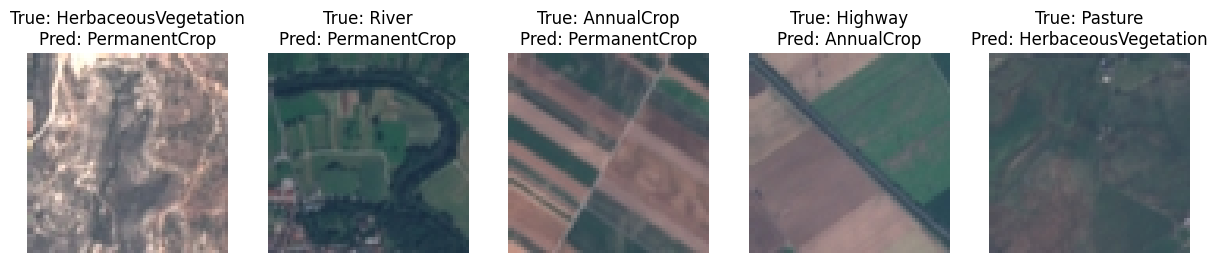

In [ ]:
%matplotlib inline
### ------ MISCLASSIFIED SAMPLES ------
def plot_misclassified_samples(model: nn.Module, df: pd.DataFrame, data_loader: torch.utils.data.DataLoader, num_samples: int = 5):
    model.eval()
    misclassified = []
    with torch.inference_mode():
        for batch_idx, (X, y) in enumerate(data_loader):
            X, y = X.to(device), y.to(device)
            y_logits = model(X)
            y_preds = y_logits.argmax(dim=1)
            mismatch = (y_preds.cpu() != y.cpu()).nonzero(as_tuple=False).flatten()
            for i in mismatch:
                global_idx = batch_idx * data_loader.batch_size + i.item()
                misclassified.append((global_idx, y[i].item(), y_preds[i].item()))
            if len(misclassified) >= num_samples:
                break

    chosen = misclassified[:num_samples]

    plt.figure(figsize=(15, 3))

    for i, (idx, true_label_idx, pred_label_idx) in enumerate(chosen):
        sample = df.iloc[idx]

        folder = sample["folder"]
        file_name = sample["file_name"]
        true_label = class_labels[true_label_idx]
        pred_label = class_labels[pred_label_idx]

        image_full_path = os.path.join(folder, file_name)
        image = Image.open(image_full_path).convert("RGB")

        plt.subplot(1, num_samples, i + 1)
        plt.imshow(image)
        plt.title(f"True: {true_label}\nPred: {pred_label}")
        plt.axis("off")

    os.makedirs("assets/plots", exist_ok=True)
    plt.savefig("assets/plots/misclassified_samples.png")
    plt.show()

plot_misclassified_samples(satellite_model, df_validation_data, validation_dataloader, num_samples=5)

### Test Set

In [ ]:
# your code goes here (preprocess_test_data)
# ------- PREPROCESS DATA -----
import pandas as pd

def preprocess_test_data(data_folder: str) -> tuple[pd.DataFrame, dict]:
    
    """Processed the test data from the data folder path provided,

    Args:
        data_folder (str): The path of the folder containing the data files ( - images in its class type folder)

    Returns:
            pd.Dataframe: A dataframe containing the processed data (index, folder(str), file_name(str)).
    """

    satellite_test_data = []

    file_names = os.listdir(data_folder) # lists all the files in a class folder

    for file_name in file_names:
        satellite_test_data.append({
            "folder": data_folder,
            "file_name": file_name,
        })
    df_satellite_test_data = pd.DataFrame(satellite_test_data)
    return df_satellite_test_data
    ...

df_satellite_test_data = preprocess_test_data("public_test_data")
df_satellite_test_data

,folder,file_name
0,public_test_data,23.jpg
1,public_test_data,5016.jpg
2,public_test_data,4521.jpg
3,public_test_data,9508.jpg
4,public_test_data,3809.jpg
...,...,...
1975,public_test_data,557.jpg
1976,public_test_data,9863.jpg
1977,public_test_data,12.jpg
1978,public_test_data,7213.jpg


In [ ]:
# TEST DATASET AND DATALOADER
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
from PIL import Image

class SatelliteTestDataset(Dataset):
    def __init__(self, df: pd.DataFrame, transform=None):
        """
        Args:
            df (pd.DataFrame): dataframe containing folder, filename of the test datasets
            transform (transforms.Compose, optional): The transformations to apply to the images
        """
        self.df = df.reset_index(drop=True)
        self.transform = transform
    
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        folder = row["folder"]
        file_name = row["file_name"]

        img_full_path = os.path.join(folder, file_name)

        img = Image.open(img_full_path).convert("RGB")

        if self.transform:
            img = self.transform(img)
        
        return img, file_name

testing_datasets = SatelliteTestDataset(df_satellite_test_data, transform=validation_transform) 
testing_dataloader = DataLoader(testing_datasets, batch_size=BATCH_SIZE, shuffle=True)



In [ ]:
# MODULE EVALUATION
predictions: list[dict[str, str]] = [] # list of predictions with file_name and predicted labels

satellite_model.eval()
with torch.inference_mode():
    for batch, (images, file_names) in tqdm(enumerate(testing_dataloader)):
        images = images.to(device)

        # Forward pass
        y_preds_logits = satellite_model(images)
        y_preds_labels = y_preds_logits.argmax(dim=1)

        for file_name, label in zip(file_names, y_pred_labels.cpu().numpy()):
            predictions.append({"file_name": file_name, "label": class_labels[label]})
predictions[:10]

62it [00:08,  7.41it/s]


['3410.jpg, River',
 '6919.jpg, Pasture',
 '6414.jpg, PermanentCrop',
 '8875.jpg, Residential',
 '8759.jpg, Industrial',
 '1248.jpg, Residential',
 '2460.jpg, Highway',
 '2909.jpg, AnnualCrop',
 '7622.jpg, River',
 '657.jpg, Pasture']

In [ ]:
# CREATION OF CSV FILE

# with open("submission.csv", "w") as f:
#     for prediction_line in predictions:
#         f.write(prediction_line + "\n")
pd.DataFrame(predictions).to_csv("submission.csv", index=False, header=False)

In [ ]:
from tqdm import tqdm

preds_loss = 0
preds_acc = 0
satellite_model.eval()
with torch.inference_mode():
    for (X, y) in tqdm(validation_dataloader):
        # Move data and labels to device
        X, y = X.to(device), y.to(device)

        # Forward pass
        y_preds_logits = satellite_model(X)
        y_preds = y_preds_logits.argmax(dim=1)

        # Calculate the loss and accuracy
        preds_loss += loss_fn(y_preds_logits, y)
        preds_acc +=  (y_preds == y).float().mean().item()

    # Calculate the average loss and accuracy
    preds_loss /= len(validation_dataloader)
    preds_acc /= len(validation_dataloader)

print(r"-------------------------------------------|")
print(f"Result for Evaluation of untrained model")
print(f"Loss: {preds_loss:.5f} | Accuracy: {preds_acc:.2f}")
print(r"-------------------------------------------|")

100%|██████████| 63/63 [00:08<00:00,  7.01it/s]

-------------------------------------------|
Result for Evaluation of untrained model
Loss: 0.11642 | Accuracy: 0.96
-------------------------------------------|
